In [1]:
from typing import TypedDict , List,NotRequired
from langgraph.graph import StateGraph , START, END

In [2]:
class AgentState(TypedDict):
  values: List[int]
  name: str
  result: str

In [3]:
def process_vals(state: AgentState) -> AgentState:
  """this function handles different type of data"""
  state["result"]=f"Hi {state["name"]}! the sum of values is {sum(state["values"])}"
  return state

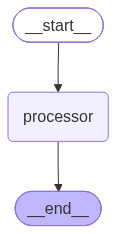

In [4]:
graph=StateGraph(AgentState)
graph.add_node("processor",process_vals)
graph.set_entry_point("processor")
graph.set_finish_point("processor")
app=graph.compile()
from IPython.display import display , Image
display(Image(app.get_graph().draw_mermaid_png()))

In [5]:
print(app.invoke({"name":"Booby" , "values":[1,2,3,4,5]})["result"])

Hi Booby! the sum of values is 15


**Excercise 3**

In [6]:
class AgentState(TypedDict):
  name: str
  age: int
  skills: List[str]
  result: str

In [7]:
def greeting(state: AgentState) -> AgentState:
  """Greeting the person with name"""
  # Ensure result is initialized
  state["result"] = f"Hi {state['name']}!"
  return state

def tell_age(state: AgentState) -> AgentState:
  """Say the age of the person"""
  # Use .get() or check if key exists to avoid KeyError
  current_res = state.get("result", "")
  state["result"] = current_res + f" You are {state['age']} years old."
  return state

def tell_skills(state: AgentState) -> AgentState:
  """Tell the skills of the person"""
  current_res = state.get("result", "")
  skills_str = ", ".join(state["skills"])
  state["result"] = current_res + f" You have the following skills: {skills_str}."
  return state

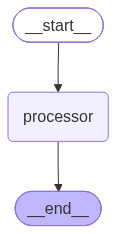

In [8]:
graph=StateGraph(AgentState)
graph.add_node("greeting",greeting)
graph.add_node("tell_age",tell_age)
graph.add_node("tell_skills",tell_skills)
graph.add_edge("greeting","tell_age")
graph.add_edge("tell_age","tell_skills")
graph.set_entry_point("greeting")
graph.set_finish_point("tell_skills")
app1=graph.compile()
from IPython.display import display , Image
display(Image(app.get_graph().draw_mermaid_png()))

In [9]:
dictionary={"name":"Booby" , "age":27 ,"skills":["Python","SQL","PowerBI","ML"]}
print(app1.invoke(dictionary)["result"])

Hi Booby! You are 27 years old. You have the following skills: Python, SQL, PowerBI, ML.


In [10]:
class AgentState(TypedDict):
  num1: int
  ops: str
  num2: int
  result: int

In [11]:
def adder(state:AgentState) -> AgentState:
  """perform this operation if ops is a + sign or plus or add"""
  state["result"]=state["num1"]+state["num2"]
  return state

def subtracter(state:AgentState) -> AgentState:
  """perform this operation if ops is a - sign or minus or subtract"""
  state["result"]=state["num1"]-state["num2"]
  return state

def multiplier(state:AgentState) -> AgentState:
  """perform this operation if ops is a * sign or multiply or cross or x or X"""
  state["result"]=state["num1"]*state["num2"]
  return state

def divider(state:AgentState) -> AgentState:
  """perform this operation if ops is a / sign or divide"""
  state["result"]=state["num1"]/state["num2"]
  return state

def router (state:AgentState)-> str:
  """decides next node based on ops"""
  if state["ops"] in ["+","plus","add"]:
    return "adder"
  elif state["ops"] in ["-","minus","subtract"]:
    return "subtracter"
  elif state["ops"] in ["*","multiply","cross","x","X"]:
    return "multiplier"
  elif state["ops"] in ["/","divide"]:
    return "divider"
  else:
    raise ValueError(f"Invalid operation: {state['ops']}")

In [12]:
graphCalc=StateGraph(AgentState)
graphCalc.add_node("adder",adder)
graphCalc.add_node("subtracter",subtracter)
graphCalc.add_node("multiplier",multiplier)
graphCalc.add_node("divider",divider)
graphCalc.add_node("router",lambda state:state)
graphCalc.set_entry_point("router")
graphCalc.add_conditional_edges("router",router,
                                {
                                    "adder":"adder",
                                    "subtracter":"subtracter",
                                    "multiplier":"multiplier",
                                    "divider":"divider"
                                }
                                )
graphCalc.set_finish_point(["adder","subtracter","multiplier","divider"])
calc=graphCalc.compile()

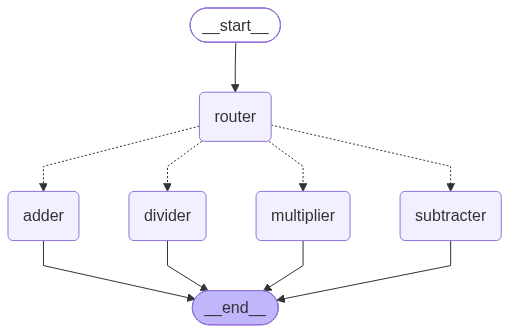

In [13]:
from IPython.display import Image, display
display(Image(calc.get_graph().draw_mermaid_png()))

In [14]:
initial_state_1 = AgentState(num1 = 10, ops="multiply", num2 = 5)
print(calc.invoke(initial_state_1))

{'num1': 10, 'ops': 'multiply', 'num2': 5, 'result': 50}


In [15]:
class AgentState(TypedDict):
  num1: int
  ops: str
  num2: int
  num3: int
  ops2: str
  result: int

In [16]:
def adder(state:AgentState) -> AgentState:
  """perform this operation if ops is a + sign or plus or add"""
  state["result"]=state["num1"]+state["num2"]
  return state

def subtracter(state:AgentState) -> AgentState:
  """perform this operation if ops is a - sign or minus or subtract"""
  state["result"]=state["num1"]-state["num2"]
  return state

def multiplier(state:AgentState) -> AgentState:
  """perform this operation if ops is a * sign or multiply or cross or x or X"""
  state["result"]=state["num1"]*state["num2"]
  return state

def divider(state:AgentState) -> AgentState:
  """perform this operation if ops is a / sign or divide"""
  state["result"]=state["num1"]/state["num2"]
  return state

def router (state:AgentState)-> str:
  """decides next node based on ops"""
  print("ROUTER RECEIVED:", state)
  if state["ops"] in ["+","plus","add"]:
    return "adder"
  elif state["ops"] in ["-","minus","subtract"]:
    return "subtracter"
  elif state["ops"] in ["*","multiply","cross","x","X"]:
    return "multiplier"
  elif state["ops"] in ["/","divide"]:
    return "divider"
  else:
    raise ValueError(f"Invalid operation: {state['ops']}")
def saver(state:AgentState)->AgentState:
  """saves the result of first operation"""
  state["num1"]=state["result"]
  state["num2"]=state["num3"]
  state["ops"]=state["ops2"]
  print("AFTER SAVER:", state)
  return state

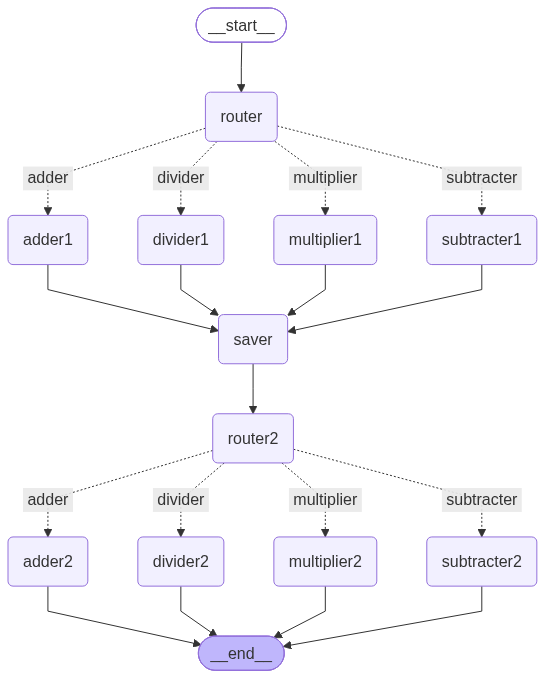

In [17]:
graphCalc=StateGraph(AgentState)
graphCalc.add_node("router",lambda state:state)
graphCalc.add_node("adder1",adder)
graphCalc.add_node("subtracter1",subtracter)
graphCalc.add_node("multiplier1",multiplier)
graphCalc.add_node("divider1",divider)
graphCalc.add_node("saver",saver)
graphCalc.add_node("router2",lambda state:state)
graphCalc.add_node("adder2",adder)
graphCalc.add_node("subtracter2",subtracter)
graphCalc.add_node("multiplier2",multiplier)
graphCalc.add_node("divider2",divider)
# graphCalc.set_entry_point("router")
graphCalc.add_edge(START, "router")
graphCalc.add_conditional_edges("router",router,
                                {
                                    "adder":"adder1",
                                    "subtracter":"subtracter1",
                                    "multiplier":"multiplier1",
                                    "divider":"divider1"
                                }
                                )
# graphCalc.add_edge(["adder1","subtracter1","multiplier1","divider1"],"saver")
graphCalc.add_edge("adder1", "saver")
graphCalc.add_edge("subtracter1", "saver")
graphCalc.add_edge("multiplier1", "saver")
graphCalc.add_edge("divider1", "saver")
graphCalc.add_edge("saver","router2")
graphCalc.add_conditional_edges("router2",router,
                                {
                                    "adder":"adder2",
                                    "subtracter":"subtracter2",
                                    "multiplier":"multiplier2",
                                    "divider":"divider2"
                                }
                                )
# graphCalc.set_finish_point(["adder2","subtracter2","multiplier2","divider2"])

graphCalc.add_edge("adder2", END)
graphCalc.add_edge("subtracter2", END)
graphCalc.add_edge("multiplier2", END)
graphCalc.add_edge("divider2", END)
calc1=graphCalc.compile()
from IPython.display import Image, display
display(Image(calc1.get_graph().draw_mermaid_png()))

In [18]:
initial_state_2={"num1": 5,"ops": "*","num2": 10,"num3": 20,"ops2": "-"}
print(calc1.invoke(initial_state_2))

ROUTER RECEIVED: {'num1': 5, 'ops': '*', 'num2': 10, 'num3': 20, 'ops2': '-'}
AFTER SAVER: {'num1': 50, 'ops': '-', 'num2': 20, 'num3': 20, 'ops2': '-', 'result': 50}
ROUTER RECEIVED: {'num1': 50, 'ops': '-', 'num2': 20, 'num3': 20, 'ops2': '-', 'result': 50}
{'num1': 50, 'ops': '-', 'num2': 20, 'num3': 20, 'ops2': '-', 'result': 30}


In [19]:
class AgentState(TypedDict):
    player_name: str
    target_number: int
    guesses: List[int]
    attempts: int
    hint: str
    lower_bound: int 
    upper_bound: int 

In [31]:
import random
x=random.randint(1,20)
def InitTheNum(state:AgentState) -> AgentState:
  """this function initializes the number"""
  print(f"hi {state["player_name"]},welcome to the game target is {x}")
  state["target_number"]=x
  state["guesses"]=[]
  state["attempts"]=0
  state["hint"] = "Game started! Try to guess the number."
  state["lower_bound"] = 1 
  state["upper_bound"] = 20
  return state

def GuessTheNum(state:AgentState) -> AgentState:
  """this function saves guessed number"""
  simulated_guess = random.randint(state["lower_bound"], state["upper_bound"])
  state["guesses"].append(simulated_guess)
  state["attempts"] += 1
  return state

def referee_processor(state:AgentState) -> AgentState:
  """Processes the guess and prints feedback, always returns the state"""
  last_guess = state["guesses"][-1]
  if state["target_number"] == last_guess:
    state["hint"] = "correct"
    print(f"Congratulations {state['player_name']}! You guessed the number {state['target_number']} in {state['attempts']} tries.")
  elif state["target_number"] > last_guess:
    state["lower_bound"] = last_guess + 1
    state["hint"] = "go high"
    print("u guessed low")
  else: # state["target_number"] < last_guess
    state["upper_bound"] = last_guess - 1
    state["hint"] = "go low"
    print("u guessed high")
  return state


def attempt_counter(state:AgentState)->AgentState:
  """Counts the number of attempts and checks if the player has lost"""
  if state["attempts"] >= 7 and state["target_number"] != state["guesses"][-1]:
    state["hint"] = "you lost"
    print("you lost")

  print(state["guesses"])
  print(f"attempts:{state['attempts']}")
  return state

def referee_router(state:AgentState) -> str:
  """Decides whether to loop for another guess or exit based on state"""
  if state["hint"] == "correct" or state["hint"] == "you lost":
    return "exit"
  else:
    return "loop"

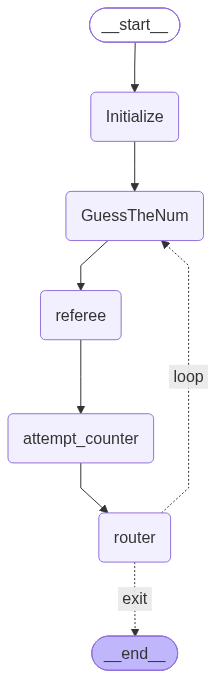

In [32]:
gg=StateGraph(AgentState)
gg.add_node("Initialize",InitTheNum)
gg.add_node("GuessTheNum",GuessTheNum)
gg.add_node("referee",referee_processor)
gg.add_node("attempt_counter",attempt_counter)
gg.add_node("router",lambda state:state)
gg.add_edge(START,"Initialize")
gg.add_edge("Initialize","GuessTheNum")
gg.add_edge("GuessTheNum","referee")
gg.add_edge("referee","attempt_counter")
gg.add_edge("attempt_counter","router")
gg.add_conditional_edges("router",referee_router,
                         {
                             "exit":END,
                             "loop":"GuessTheNum"
                         }
                         )
ggApp=gg.compile()
from IPython.display import Image, display
display(Image(ggApp.get_graph().draw_mermaid_png()))

In [38]:
result = ggApp.invoke({"player_name": "Student", "guesses": [], "attempts": 0, "lower_bound": 1, "upper_bound": 20})

hi Student,welcome to the game target is 12
u guessed low
[2]
attempts:1
u guessed high
[2, 16]
attempts:2
u guessed low
[2, 16, 8]
attempts:3
u guessed low
[2, 16, 8, 11]
attempts:4
u guessed high
[2, 16, 8, 11, 15]
attempts:5
u guessed high
[2, 16, 8, 11, 15, 14]
attempts:6
u guessed high
you lost
[2, 16, 8, 11, 15, 14, 13]
attempts:7


15
